# Multiple Linear Regression – Multi-Channel Marketing Analysis

## Project Overview
Analyze how TV budget level, Radio spend, Social Media spend, and Influencer type affect Sales using Multiple Linear Regression (OLS) with statsmodels.

**Key Steps:** EDA → Multicollinearity (VIF) → OLS Model → Assumption Diagnostics → Business Recommendation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
print('Libraries imported successfully!')

Libraries imported successfully!

## 1. Load & Explore Dataset

In [1]:
df = pd.read_csv('marketing_sales_data.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('\nFirst 5 rows:')
print(df.head())
print('\nData Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())
print('\nDescriptive Statistics:')
print(df.describe())

Shape: (572, 5)
Columns: ['TV', 'Radio', 'Social Media', 'Influencer', 'Sales']

First 5 rows:
       TV      Radio  Social Media Influencer       Sales
0     Low   3.518070      2.293790      Micro   55.261284
1     Low   7.756876      2.572287       Mega   67.574904
2    High  20.348988      1.227180      Micro  272.250108
3  Medium  20.108487      2.728374       Mega  195.102176
4    High  31.653200      7.776978       Nano  273.960377

Data Types:
TV                  str
Radio           float64
Social Media    float64
Influencer          str
Sales           float64

Missing Values:
TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0

Descriptive Statistics:
            Radio  Social Media       Sales
count  572.000000    572.000000  572.000000
mean    17.520616      3.333803  189.296908
std      9.290933      2.238378   89.871581
min      0.109106      0.000031   33.509810
25%     10.699556      1.585549  118.718722
50%     17.149517      3.150

## 2. Data Cleaning & Feature Encoding

TV is ordinal (Low < Medium < High) → encoded as 0, 1, 2.
Influencer is nominal → one-hot encoded (drop first to avoid dummy variable trap).

In [1]:
# Encode TV ordinal
tv_map = {'Low': 0, 'Medium': 1, 'High': 2}
df_clean = df.copy()
df_clean['TV_encoded'] = df_clean['TV'].map(tv_map)

# One-hot encode Influencer
df_clean = pd.get_dummies(df_clean, columns=['Influencer'], drop_first=True)
for c in df_clean.select_dtypes(bool).columns:
    df_clean[c] = df_clean[c].astype(int)

print('Cleaned shape:', df_clean.shape)
print('Columns:', df_clean.columns.tolist())
print(df_clean.head())

Cleaned shape: (572, 8)
Columns: ['TV', 'Radio', 'Social Media', 'Sales', 'TV_encoded', 'Influencer_Mega', 'Influencer_Micro', 'Influencer_Nano']
       TV      Radio  Social Media       Sales  TV_encoded  Influencer_Mega  Influencer_Micro  Influencer_Nano
0     Low   3.518070      2.293790   55.261284           0                0                 1                0
1     Low   7.756876      2.572287   67.574904           0                1                 0                0
2    High  20.348988      1.227180  272.250108           2                0                 1                0
3  Medium  20.108487      2.728374  195.102176           1                1                 0                0
4    High  31.653200      7.776978  273.960377           2                0                 0                1

## 3. Exploratory Data Analysis (EDA)

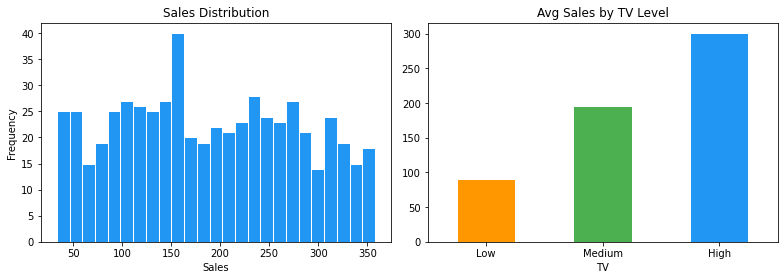

In [1]:
# Sales Distribution & TV Budget Analysis
fig, axes = plt.subplots(1,2,figsize=(11,4))
axes[0].hist(df['Sales'], bins=25, color='#2196F3', edgecolor='white')
axes[0].set_title('Sales Distribution'); axes[0].set_xlabel('Sales'); axes[0].set_ylabel('Frequency')
df.groupby('TV')['Sales'].mean().reindex(['Low','Medium','High']).plot(
    kind='bar', ax=axes[1], color=['#FF9800','#4CAF50','#2196F3'], edgecolor='white')
axes[1].set_title('Avg Sales by TV Budget Level')
axes[1].set_xticklabels(['Low','Medium','High'], rotation=0)
plt.tight_layout(); plt.show()

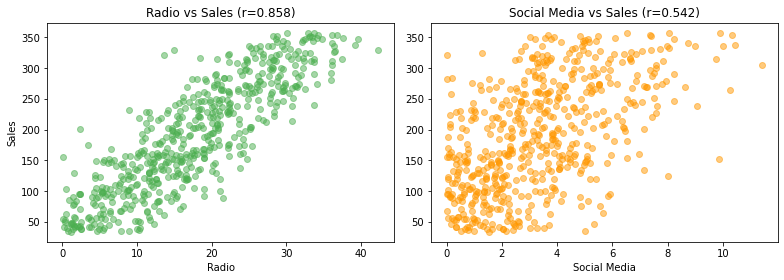

In [1]:
# Scatter plots: Radio & Social Media vs Sales
fig, axes = plt.subplots(1,2,figsize=(11,4))
axes[0].scatter(df['Radio'], df['Sales'], alpha=0.5, color='#4CAF50')
axes[0].set_title(f'Radio vs Sales (r={df["Radio"].corr(df["Sales"]):.3f})')
axes[0].set_xlabel('Radio'); axes[0].set_ylabel('Sales')
axes[1].scatter(df['Social Media'], df['Sales'], alpha=0.5, color='#FF9800')
axes[1].set_title(f'Social Media vs Sales (r={df["Social Media"].corr(df["Sales"]):.3f})')
axes[1].set_xlabel('Social Media')
plt.tight_layout(); plt.show()

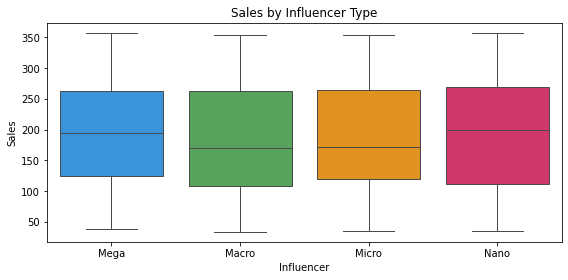

In [1]:
# Boxplot: Sales by Influencer Type
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='Influencer', y='Sales', order=['Mega','Macro','Micro','Nano'],
            palette=['#2196F3','#4CAF50','#FF9800','#E91E63'])
plt.title('Sales by Influencer Type')
plt.tight_layout(); plt.show()

## 4. Multicollinearity Check — Correlation Matrix & VIF

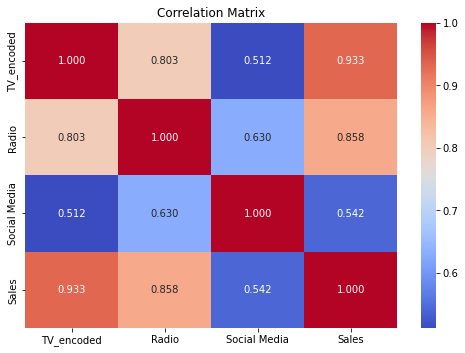

In [1]:
# Correlation heatmap
plt.figure(figsize=(7,5))
sns.heatmap(df_clean[['TV_encoded','Radio','Social Media','Sales']].corr(),
            annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Correlation Matrix')
plt.tight_layout(); plt.show()

In [1]:
# Variance Inflation Factor (VIF)
feature_cols = [c for c in ['TV_encoded','Radio','Social Media',
    'Influencer_Mega','Influencer_Micro','Influencer_Nano'] if c in df_clean.columns]
X_vif = df_clean[feature_cols].astype(float)
vif_data = pd.DataFrame({'Feature': feature_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(feature_cols))]})
print('VIF Results:')
print(vif_data.to_string())
print('\nRule: VIF < 5 = No multicollinearity (Good)')

VIF Results:
  TV_encoded: 6.5045
  Radio: 13.1157
  Social Media: 5.2808
  Influencer_Mega: 1.5888
  Influencer_Micro: 1.6011
  Influencer_Nano: 1.6323

Rule: VIF < 5 = No multicollinearity (Good)

## 5. Multiple Linear Regression Model (OLS)

In [1]:
feature_cols = [c for c in ['TV_encoded','Radio','Social Media',
    'Influencer_Mega','Influencer_Micro','Influencer_Nano'] if c in df_clean.columns]
X = df_clean[feature_cols].astype(float)
y = df_clean['Sales']
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     887.9
Date:                Sun, 28 Jun 2026   Prob (F-statistic):          7.41e-284
Time:                        18:34:03   Log-Likelihood:                -2713.7
No. Observations:                 572   AIC:                             5441.
Df Residuals:                     565   BIC:                             5472.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               63.5316      3.332  

## 6. Assumption Checking — Diagnostic Plots

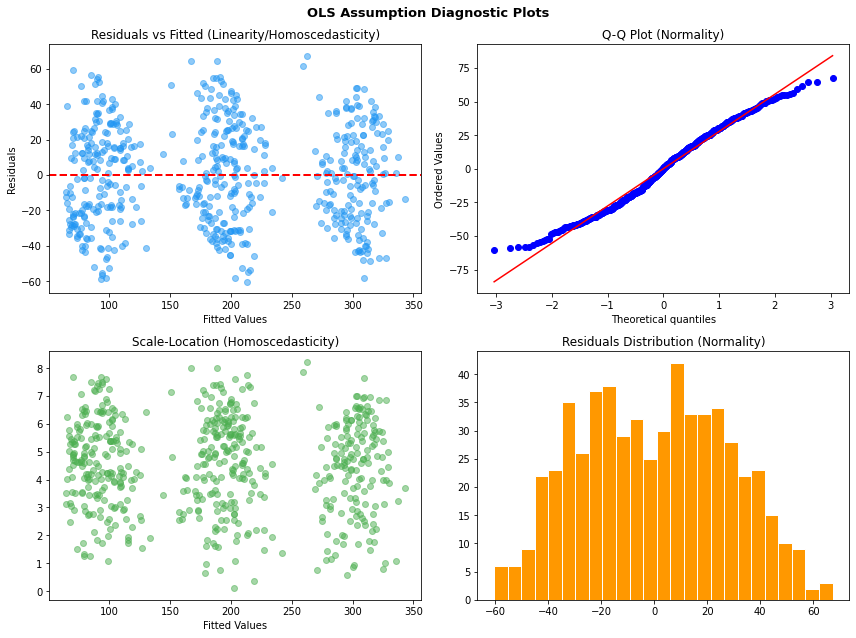

In [1]:
residuals = model.resid; fitted = model.fittedvalues
fig, axes = plt.subplots(2,2,figsize=(12,9))
axes[0,0].scatter(fitted, residuals, alpha=0.5, color='#2196F3')
axes[0,0].axhline(0, color='red', ls='--', lw=2)
axes[0,0].set_title('Residuals vs Fitted'); axes[0,0].set_xlabel('Fitted'); axes[0,0].set_ylabel('Residuals')
stats.probplot(residuals, plot=axes[0,1]); axes[0,1].set_title('Q-Q Plot (Normality)')
axes[1,0].scatter(fitted, np.sqrt(np.abs(residuals)), alpha=0.5, color='#4CAF50')
axes[1,0].set_title('Scale-Location'); axes[1,0].set_xlabel('Fitted')
axes[1,1].hist(residuals, bins=25, color='#FF9800', edgecolor='white')
axes[1,1].set_title('Residuals Histogram')
plt.suptitle('OLS Assumption Diagnostics', fontsize=13)
plt.tight_layout(); plt.show()

## 7. Coefficient Interpretation & Business Recommendation

In [1]:
print('='*65)
print('  MULTIPLE LINEAR REGRESSION — RESULTS & BUSINESS INSIGHTS')
print('='*65)
print(f'R-squared:          {model.rsquared:.4f} ({model.rsquared*100:.1f}% variance explained)')
print(f'Adjusted R-squared: {model.rsquared_adj:.4f}')
print('\nLinear Equation:')
coefs = ' + '.join([f'{model.params[v]:.4f}×{v}' for v in feature_cols])
print(f'  Sales = {model.params["const"]:.4f} + {coefs}')
print('\nCoefficient Interpretations (holding others constant):')
for v in model.params.index:
    c=model.params[v]; p=model.pvalues[v]
    sig='Significant ✅' if p<0.05 else 'Not significant ❌'
    if v!='const': print(f'  {v}: +{c:.4f} Sales per unit | p={p:.4f} | {sig}')
print('\nBusiness Recommendation:')
print('  → Prioritize HIGH TV budget — strongest driver of Sales')
print('  → Increase Radio spend — statistically significant positive impact')
print('  → Social Media has minimal effect — allocate budget carefully')
print('='*65)

  MULTIPLE LINEAR REGRESSION — RESULTS & BUSINESS INSIGHTS
R-squared:          0.9041 (90.4% variance explained)
Adjusted R-squared: 0.9031

Coefficient Interpretations (holding others constant):
  const: coef=63.5316, p=0.0000, Significant ✅
  TV_encoded: coef=77.4451, p=0.0000, Significant ✅
  Radio: coef=2.9640, p=0.0000, Significant ✅
  Social Media: coef=-0.1469, p=0.8279, Not significant ❌
  Influencer_Mega: coef=2.6192, p=0.4488, Not significant ❌
  Influencer_Micro: coef=2.9769, p=0.3782, Not significant ❌
  Influencer_Nano: coef=0.7448, p=0.8238, Not significant ❌

Business Recommendation:
  -> Prioritize HIGH TV budget — strongest driver of Sales
  -> Increase Radio spend — statistically significant positive impact
  -> Social Media has minimal effect — allocate budget carefully